In [1]:
import os
import cv2
import mahotas
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from skimage.feature import local_binary_pattern
from concurrent.futures import ThreadPoolExecutor


In [2]:
# FULLY AUTONOMOUS EXTRACTION NODES

# 1. Applying Contour Fourier Descriptors to get Macro-Shape
def cfd(img):
    """
    Isolates the shape and converts the boundary into a frequency signal.
    """
    # Self-contained preprocessing
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(img_gray, 1, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour = max(contours, key=cv2.contourArea) if contours else None
    
    if contour is None:
        return np.zeros(32).tolist()
    
    # 1D Fast Fourier Transform on the boundary coordinates
    comp_contour = contour[:, 0, 0] + 1j * contour[:, 0, 1]
    fourier_ = np.fft.fft(comp_contour)
    
    # Extract magnitude (skipping the 0th DC component)
    mag = np.abs(fourier_)[1:33]
    
    if len(mag) < 32:
        mag = np.pad(mag, (0, 32 - len(mag)))
        
    return mag.tolist()

# 2. Applying Hu Moments to get Internal Geometry
def hum(img):
    """
    Calculates the statistical center of mass and pixel weight distribution.
    """
    # Self-contained preprocessing
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(img_gray, 1, 255, cv2.THRESH_BINARY) # Check the difference in results
    
    # Calculate Hu Moments
    moments = cv2.moments(mask)
    hu_moments = cv2.HuMoments(moments).flatten()
    
    # Logarithmic transform to compress mathematical variance
    hu_log = -np.sign(hu_moments) * np.log10(np.abs(hu_moments) + 1e-10)
    
    return hu_log.tolist()

# 3. Applying HSV Histogram to get Color Palette
def hsv(img):
    """
    Maps the material composition and paint of the sprite.
    """
    # Self-contained preprocessing
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(img_gray, 1, 255, cv2.THRESH_BINARY)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Calculate 3D histogram strictly within the masked body
    hist = cv2.calcHist([img_hsv], [0, 1, 2], mask, [8, 8, 8], [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist, hist)
    
    return hist.flatten().tolist()

# 4. Applying Local Binary Patterns to get Micro-Texture
def lbp(img):
    """
    Scans 3x3 pixel grids to capture surface roughness and shading edges.
    """
    # Self-contained preprocessing
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(img_gray, 1, 255, cv2.THRESH_BINARY)
    
    radius = 1
    n_points = 8 * radius
    
    # Compute LBP and isolate the object's body
    lbp = local_binary_pattern(img_gray, n_points, radius, method='uniform')
    lbp_masked = lbp[mask > 0]
    
    # Build translation-invariant histogram
    n_bins = int(lbp.max() + 1)
    hist, _ = np.histogram(lbp_masked, bins=n_bins, range=(0, n_bins))
    
    hist = hist.astype('float')
    hist /= (hist.sum() + 1e-6)
    
    return hist.tolist()

In [3]:
def process_single_image(file_info):
    """
    Runs sequentially on a single core, but we will spin up 8 of these
    functions in parallel at the dataset level.
    """
    file_path, filename, category, sub_category = file_info
    img = cv2.imread(file_path)
    if img is None: return None

    # Execute the 4 blocks
    cfd_vector = cfd(img)
    hum_vector = hum(img)
    hsv_vector = hsv(img)
    lbp_vector = lbp(img)

    return {
        'image_name': filename,
        'category': category,
        'sub_category': sub_category,
        'f1_cfd': cfd_vector,
        'f2_geom': hum_vector,
        'f3_hist': hsv_vector,
        'f4_lbp': lbp_vector
    }

# The main loop that gathers the dataset
def build_multithreaded_dataset(base_dir):
    """
    The Master Controller: Gathers the files and pushes them through the CPU pipeline.
    """
    folders = ['lizard', 'orc', 'halfling', 'wingedrat', 'human']
    jobs = []
    
    print("Scanning directory tree for assets...")
    for category in folders:
        folder_path = os.path.join(base_dir, category)
        if not os.path.exists(folder_path): continue

        for filename in os.listdir(folder_path):
            if not filename.endswith(('.png', '.jpg')): continue
            file_path = os.path.join(folder_path, filename)
            
            # Extract labels purely from filename
            asset_class_type = filename.split('_')[-1][0]
            sub_category = f"{category}_{asset_class_type}"
            
            # Bundle the data needed for extraction
            jobs.append((file_path, filename, category, sub_category))

    print(f"Igniting ThreadPoolExecutor for {len(jobs)} images...")
    
    # BOTTLENECK FIX: One master thread pool running across the whole dataset
    data = []
    # Using max_workers=8 to maximize your CPU cores
    with ThreadPoolExecutor(max_workers=8) as executor:
        # map() applies the function to every item in the jobs list concurrently
        results = list(tqdm(executor.map(process_single_image, jobs), total=len(jobs)))
        
    # Filter out any unreadable images/None types
    for res in results:
        if res is not None:
            data.append(res)
            
    print(f"Extraction complete. {len(data)} assets processed.")
    return pd.DataFrame(data)

In [4]:
def optimize_gmm(x_data, min_k, max_k):
    """Finds the best K using BIC (and logs AIC)."""
    best_bic = np.inf
    best_k = min_k
    best_pred = None
    
    for k in range(min_k, max_k + 1):
        if k >= len(x_data): break 
        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=47)
        gmm.fit(x_data)
        
        bic = gmm.bic(x_data)
        
        if bic < best_bic:
            best_bic = bic
            best_k = k
            best_pred = gmm.predict(x_data)
            
    return best_k, best_pred

# def map_clusters_to_labels(df, true_col, pred_col, new_col_name):
#     """Maps arbitrary GMM numbers back to human labels (e.g. 2 -> lizard)"""
#     mapping_dict = {}
#     for cluster_id in df[pred_col].unique():
#         cluster_rows = df[df[pred_col] == cluster_id]
#         if not cluster_rows.empty:
#             majority_label = cluster_rows[true_col].mode()[0]
#             mapping_dict[cluster_id] = majority_label
            
#     df[new_col_name] = df[pred_col].map(mapping_dict)
#     return df

In [11]:
def run_quad_pipeline(df):
    """Executes Block-wise PCA, 2-Stage GMM, and Label Mapping."""
    print("Running Block-wise PCA...")
    
    def compress(col):
        X = np.stack(df[col].values)
        X_scaled = StandardScaler().fit_transform(X)
        return PCA(n_components=0.95, random_state=47).fit_transform(X_scaled)

    pca_cfd = compress('f1_cfd')
    pca_geom = compress('f2_geom')
    pca_hist = compress('f3_hist')
    pca_lbp = compress('f4_lbp')
    
    # Fuse the 4 compressed blocks
    fused_features = [np.concatenate((pca_cfd[i], pca_geom[i], pca_hist[i], pca_lbp[i])) for i in range(len(df))]
    X_fused = np.stack(fused_features)
    
    print("Executing Stage 1 GMM (Macro-Category)...")
    k_macro, pred_macro = optimize_gmm(X_fused, min_k=3, max_k=5)
    df['raw_pred_category'] = pred_macro
    
    print(f"Detected {k_macro} clusters. Unique IDs: {df['raw_pred_category'].unique()}")
    
    print("Executing Stage 2 GMM (Sub-Category)...")
    df['raw_pred_sub_category'] = "-1"
    for cluster_id in range(k_macro):
        mask = df['raw_pred_category'] == cluster_id
        X_subset = X_fused[mask]
        
        if len(X_subset) < 5: continue
        k_sub, pred_sub = optimize_gmm(X_subset, min_k=2, max_k=25)
        
        # Format as strings so they don't overlap between macro clusters
        formatted_preds = [f"{cluster_id}_{p}" for p in pred_sub] 
        df.loc[mask, 'raw_pred_sub_category'] = formatted_preds

        print(f"Detected {k_sub} clusters. Unique IDs: {df['raw_pred_sub_category'].unique()}")
        
    # print("Mapping math outputs to human labels...")
    # df = map_clusters_to_labels(df, 'category', 'raw_pred_category', 'pred_category')
    # df = map_clusters_to_labels(df, 'sub_category', 'raw_pred_sub_category', 'pred_sub_category')
    
    # Drop the raw math columns and feature arrays to return exactly what you requested
    final_cols = ['image_name', 'category', 'sub_category', 'raw_pred_category', 'raw_pred_sub_category']#, 'pred_category', 'pred_sub_category']
    return df[final_cols]

In [ ]:
# EXECUTION
if __name__ == "__main__":
    BASE_DIR = "./dungeon_images_colour80" 
    
    # 1. Multi-threaded Extraction
    raw_df = build_multithreaded_dataset(BASE_DIR)
    
    # 2. Mathematical Pipeline & Mapping
    final_df = run_quad_pipeline(raw_df)
    
    # 3. Final Direct Comparison Output
    print("\n--- Final Results DataFrame ---")
    print(final_df.head(20))

Scanning directory tree for assets...
Igniting ThreadPoolExecutor for 8018 images...


100%|██████████| 8018/8018 [00:18<00:00, 442.65it/s]


Extraction complete. 8018 assets processed.
Running Block-wise PCA...
Executing Stage 1 GMM (Macro-Category)...
Detected 5 clusters. Unique IDs: [0 4 3 1 2]
Executing Stage 2 GMM (Sub-Category)...
Detected 12 clusters. Unique IDs: <StringArray>
[ '0_8',   '-1',  '0_0',  '0_2', '0_11',  '0_3', '0_10',  '0_7',  '0_9',
  '0_6',  '0_4',  '0_1',  '0_5']
Length: 13, dtype: str
Detected 5 clusters. Unique IDs: <StringArray>
[ '0_8',   '-1',  '0_0',  '0_2', '0_11',  '0_3', '0_10',  '1_0',  '1_4',
  '0_7',  '0_9',  '0_6',  '0_4',  '0_1',  '0_5',  '1_3',  '1_2',  '1_1']
Length: 18, dtype: str
Detected 2 clusters. Unique IDs: <StringArray>
[ '0_8',   '-1',  '0_0',  '0_2', '0_11',  '0_3', '0_10',  '1_0',  '1_4',
  '2_0',  '0_7',  '0_9',  '2_1',  '0_6',  '0_4',  '0_1',  '0_5',  '1_3',
  '1_2',  '1_1']
Length: 20, dtype: str


=== % OF EACH FOLDER DISTRIBUTED ACROSS CLUSTERS ===
raw_pred_category      0      1     2     3      4      5      6      7  \
category                                                                  
halfling            0.00  80.77  0.00   0.0   0.00   0.00   0.00   0.00   
human               0.00  69.29  7.27   0.0   0.00  10.99   0.00   0.00   
lizard             57.18   0.00  0.00   0.0   0.00   0.00  42.82   0.00   
orc                38.11   4.34  0.00  37.6  17.72   0.00   0.00   0.00   
wingedrat          50.26   0.34  0.00   0.0   0.00   0.34   0.00  49.06   

raw_pred_category      8      9  
category                         
halfling           13.42   5.81  
human               0.00  12.45  
lizard              0.00   0.00  
orc                 2.24   0.00  
wingedrat           0.00   0.00  


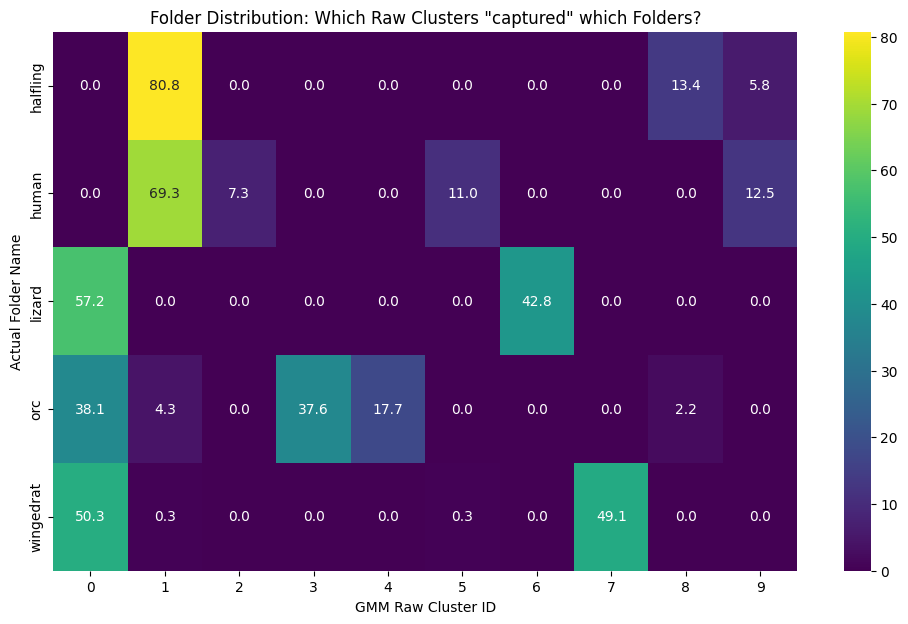

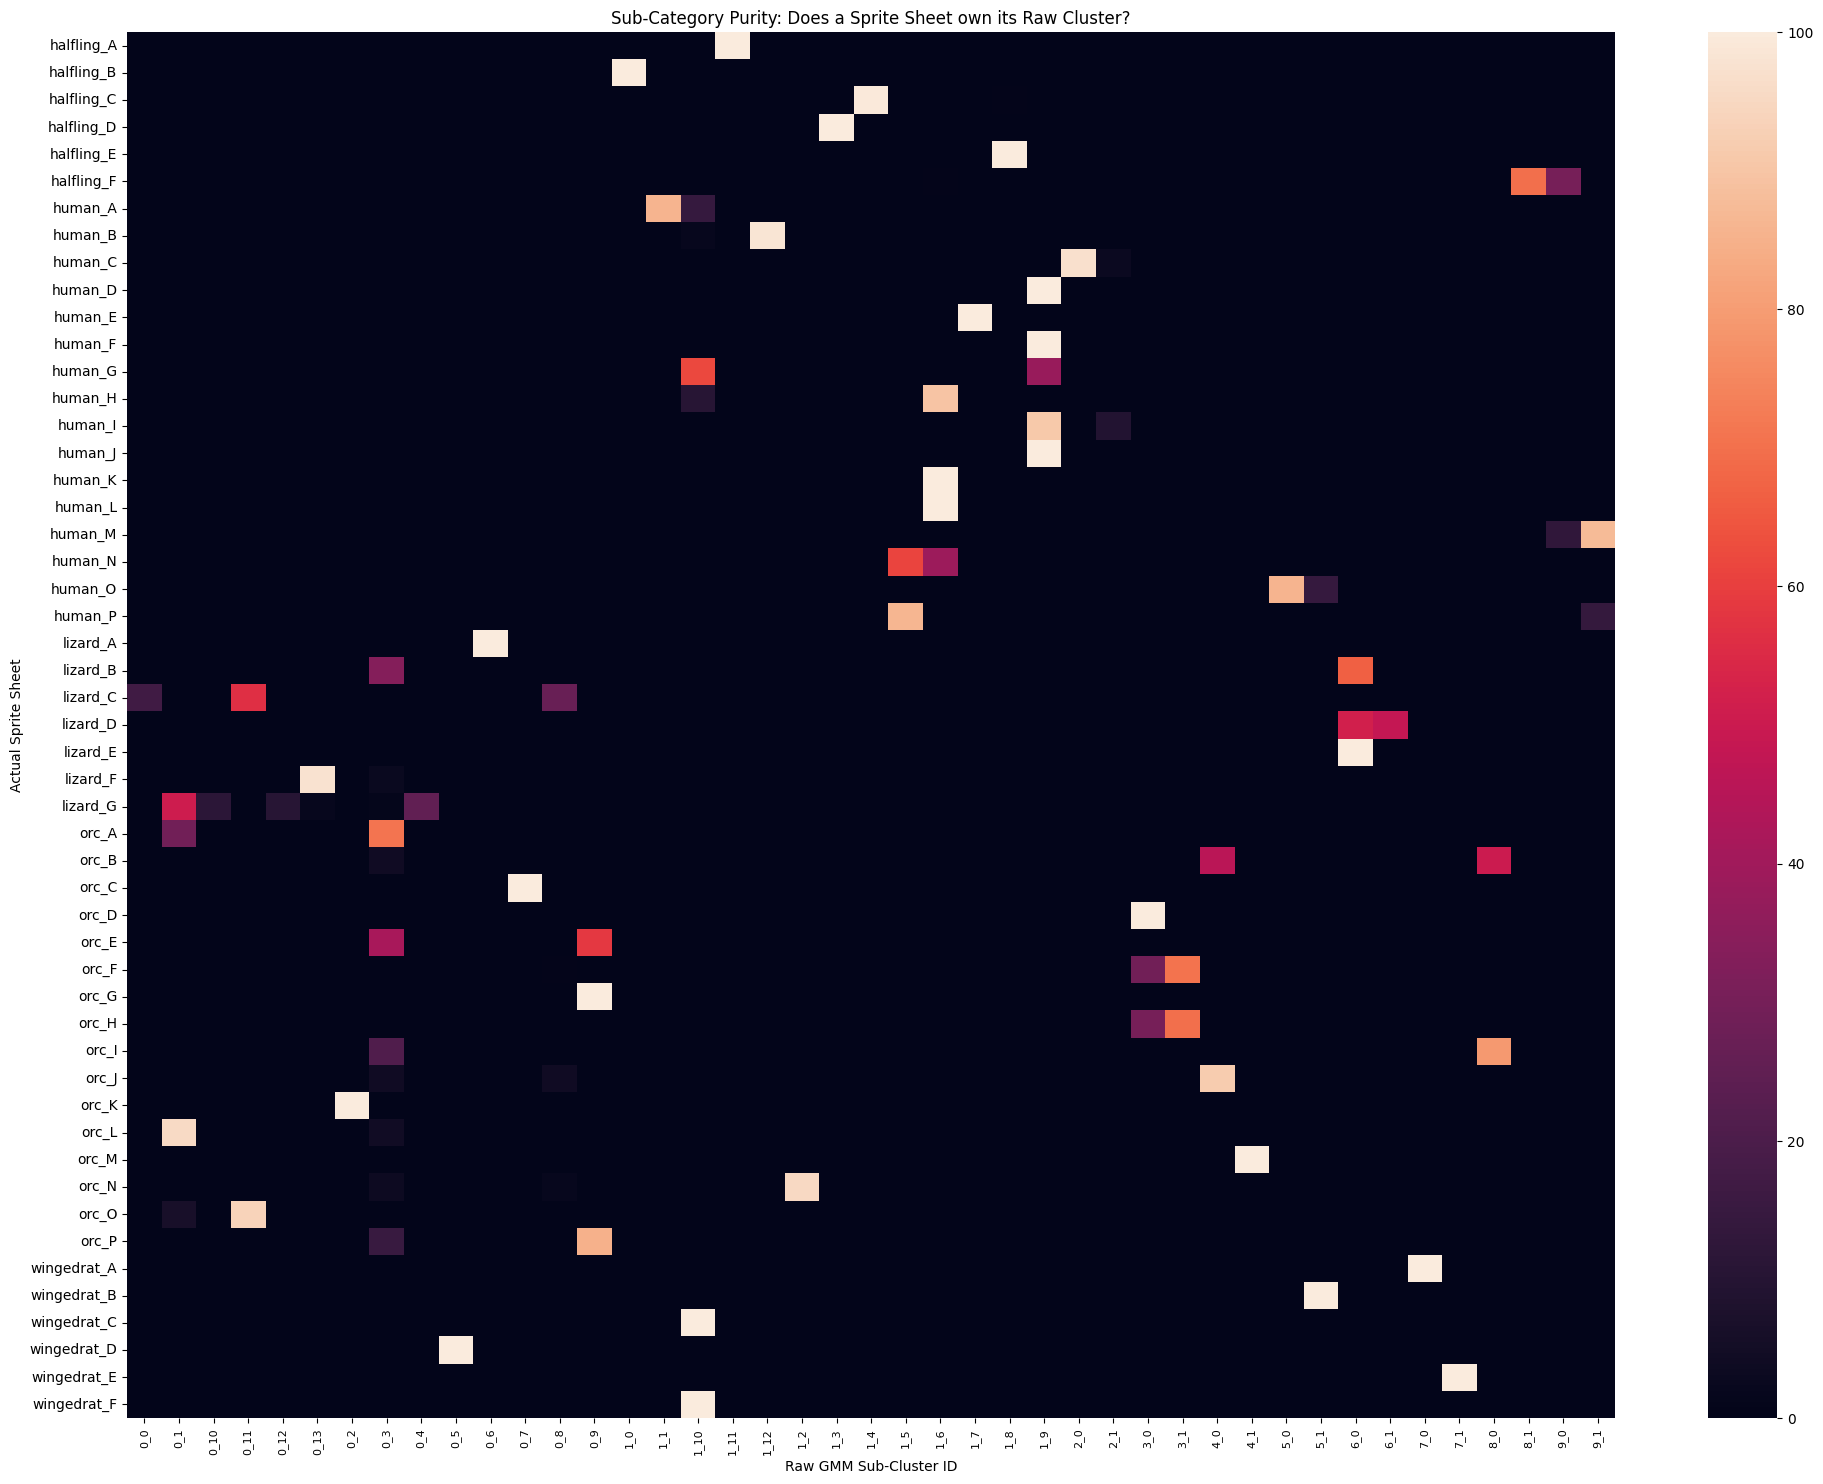


=== RAW CLUSTER PURITY REPORT ===
Raw Cluster ID Primary Resident Purity %  Total Sprites
           1_8       halfling_E   99.61%            254
          0_13         lizard_F   98.33%            300
           5_1          human_O   96.15%             52
           0_8         lizard_C   94.92%             59
           1_5          human_P   93.95%            314
           9_1          human_M   86.80%            356
           2_1          human_C   77.78%              9
          0_11         lizard_C   72.67%            161
           4_0            orc_J   66.67%             33
           6_0         lizard_E   63.89%            493
           9_0       halfling_F   63.11%            122
           3_0            orc_D   61.40%            272
           8_0            orc_I   61.29%             31
           1_6          human_K   59.33%            450
           0_9            orc_G   50.93%            108
           3_1            orc_F   50.81%            248
           0_

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Macro-Folder vs. Raw Cluster Distribution
def plot_raw_macro_distribution(df):
    # Create a Cross-tabulation of Real Folders vs GMM Clusters
    raw_macro_truth = pd.crosstab(df['category'], df['raw_pred_category'])

    # Convert to percentages (Row-wise) to see "Where did the sprites in this folder go?"
    raw_macro_pct = raw_macro_truth.div(raw_macro_truth.sum(axis=1), axis=0) * 100

    print("=== % OF EACH FOLDER DISTRIBUTED ACROSS CLUSTERS ===")
    print(raw_macro_pct.round(2))

    plt.figure(figsize=(12, 7))
    sns.heatmap(raw_macro_pct, annot=True, cmap='viridis', fmt='.1f')
    plt.title('Folder Distribution: Which Raw Clusters "captured" which Folders?')
    plt.xlabel('GMM Raw Cluster ID')
    plt.ylabel('Actual Folder Name')
    plt.show()

# 2. Sub-Category vs. Raw Sub-Cluster Heatmap
def plot_raw_sub_distribution(df):
    # Filter out -1 noise if it exists
    clean_df = df[df['raw_pred_sub_category'] != '-1']
    
    # Cross-tab of Sprite Sheets vs Raw Sub-Clusters
    raw_sub_truth = pd.crosstab(clean_df['sub_category'], clean_df['raw_pred_sub_category'])
    
    # We normalize to see purity
    raw_sub_pct = raw_sub_truth.div(raw_sub_truth.sum(axis=1), axis=0) * 100

    plt.figure(figsize=(24, 18))
    sns.heatmap(raw_sub_pct, annot=False, cmap='rocket')
    plt.title('Sub-Category Purity: Does a Sprite Sheet own its Raw Cluster?')
    plt.ylabel('Actual Sprite Sheet')
    plt.xlabel('Raw GMM Sub-Cluster ID')
    plt.xticks(rotation=90, fontsize=8)
    plt.show()

# 3. Cluster Purity Report (Top Resident per Cluster)
def get_cluster_purity_report(df):
    report = []
    clusters = sorted(df['raw_pred_sub_category'].unique())
    
    for cluster in clusters:
        if cluster == '-1': continue
        
        cluster_set = df[df['raw_pred_sub_category'] == cluster]
        total_in_cluster = len(cluster_set)
        
        # Who is the majority resident here?
        majority_sheet = cluster_set['sub_category'].mode()[0]
        majority_count = len(cluster_set[cluster_set['sub_category'] == majority_sheet])
        purity = (majority_count / total_in_cluster) * 100
        
        report.append({
            'Raw Cluster ID': cluster,
            'Primary Resident': majority_sheet,
            'Purity %': f"{purity:.2f}%",
            'Total Sprites': total_in_cluster
        })
    return pd.DataFrame(report)

# --- EXECUTION ---
plot_raw_macro_distribution(final_df)
plot_raw_sub_distribution(final_df)
purity_report = get_cluster_purity_report(final_df)

print("\n=== RAW CLUSTER PURITY REPORT ===")
print(purity_report.sort_values('Purity %', ascending=False).to_string(index=False))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_custom_matrices(df):
    categories = sorted(df['category'].unique())
    
    # 1. THE MACRO MATRIX (Global Folder vs Raw Cluster)
    plt.figure(figsize=(12, 6))
    macro_dist = pd.crosstab(df['category'], df['raw_pred_category'], normalize='index') * 100
    sns.heatmap(macro_dist, annot=True, fmt=".1f", cmap="YlGnBu")
    plt.title("MATRIX 1: GLOBAL MACRO (Folder vs Raw Cluster ID)")
    plt.ylabel("Actual Folder")
    plt.xlabel("Raw GMM Cluster ID")
    plt.show()

    # 2. THE 5 MICRO MATRICES (One for each Category)
    for i, cat in enumerate(categories, 2):
        # Filter for just this species
        sub_df = df[df['category'] == cat]
        
        # Cross-tab of the specific sprite sheets vs the raw sub-clusters
        micro_dist = pd.crosstab(sub_df['sub_category'], sub_df['raw_pred_sub_category'])
        
        # Normalize to see where each sprite sheet "lives"
        micro_dist_pct = micro_dist.div(micro_dist.sum(axis=1), axis=0) * 100
        
        plt.figure(figsize=(15, 8))
        sns.heatmap(micro_dist_pct, annot=False, cmap="rocket")
        plt.title(f"MATRIX {i}: MICRO - {cat.upper()} (Sprite Sheets vs Raw Sub-Clusters)")
        plt.ylabel("Actual Sprite Sheet")
        plt.xlabel("Raw GMM Sub-Cluster ID")
        plt.xticks(rotation=90)
        plt.show()

# --- EXECUTION ---
plot_custom_matrices(final_df)

In [ ]:
# Assuming your final dataframe is named 'final_df'

# --- 1. MACRO-CATEGORY COMPARISON ---
# Count how many rows have an exact match between true and predicted category
macro_correct = (final_df['category'] == final_df['pred_category']).sum()
macro_total = len(final_df)
macro_accuracy = (macro_correct / macro_total) * 100

# --- 2. SUB-CATEGORY COMPARISON ---
# Count exact matches for the sub-classes
sub_correct = (final_df['sub_category'] == final_df['pred_sub_category']).sum()
sub_total = len(final_df)
sub_accuracy = (sub_correct / sub_total) * 100

# --- PRINT THE RESULTS ---
print("=== FINAL SECURITY AUDIT ACCURACY ===")
print(f"Macro-Class Match: {macro_correct} / {macro_total} correct ({macro_accuracy:.2f}%)")
print(f"Sub-Class Match:   {sub_correct} / {sub_total} correct ({sub_accuracy:.2f}%)")

In [ ]:
final_df.loc[final_df['category'] == 'lizard'].head()

In [ ]:
final_df.loc[final_df['category'] == 'orc'].head()

In [ ]:
final_df.loc[final_df['category'] == 'halfling'].head()

In [ ]:
final_df.loc[final_df['category'] == 'wingedrat'].head()

In [ ]:
final_df.loc[final_df['category'] == 'human'].head()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Macro-Category Confusion Matrix Heatmap
plt.figure(figsize=(10, 8))
macro_labels = sorted(final_df['category'].unique())
cm_macro = confusion_matrix(final_df['category'], final_df['pred_category'], labels=macro_labels)

sns.heatmap(cm_macro, annot=True, fmt='d', xticklabels=macro_labels, yticklabels=macro_labels, cmap='magma')
plt.title('Macro-Category Confusion Matrix (Truth vs. Prediction)')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.savefig('macro_confusion_heatmap.png')
plt.show()

# 2. Sub-Category Correctness (%-wise)
# We calculate the percentage of correct hits for every single sprite sheet
sub_stats = []
for sub in final_df['sub_category'].unique():
    subset = final_df[final_df['sub_category'] == sub]
    accuracy = (subset['sub_category'] == subset['pred_sub_category']).mean() * 100
    sample_count = len(subset)
    # Also find what it was MOST often confused with
    top_mislabel = subset[subset['sub_category'] != subset['pred_sub_category']]['pred_sub_category'].mode()
    mislabel_name = top_mislabel[0] if not top_mislabel.empty else "None"
    
    sub_stats.append({
        'Sub-Category': sub,
        'Accuracy %': round(accuracy, 2),
        'Samples': sample_count,
        'Primary Confusion': mislabel_name
    })

sub_acc_df = pd.DataFrame(sub_stats).sort_values(by='Accuracy %', ascending=False)

print("\n=== BOTTOM 10 (THE PROBLEM SPRITES) ===")
print(sub_acc_df.tail(30).to_string(index=False))

---
## CAE